In [1]:
import cloudpickle

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [2]:
res_path = "/home/icb/lorenzo.consoli/repos/scFM_density_estimation/notebooks/rebuttal_estimation_error_effect/out/2-dims-2-loc/results.pkl"
with open(res_path, "rb") as fb:
    results_dict = cloudpickle.load(fb)


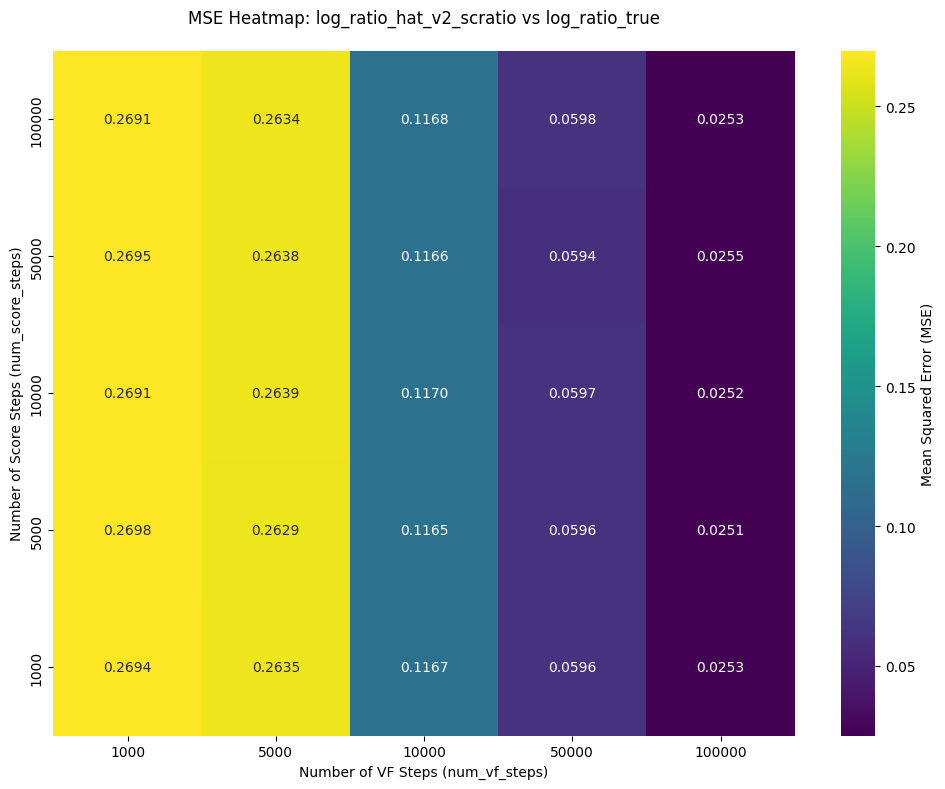

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract data and compute MSE
data = []
for num_vf_steps, vf_results in results_dict.items():
    for num_score_steps, score_results in vf_results.items():
        
        # Extract the true and predicted values (convert to numpy arrays for vector math)
        y_true = np.array(score_results['log_ratio_true'])
        y_pred = np.array(score_results['log_ratio_hat_v2_scratio']) 
        
        # Calculate Mean Squared Error
        mse = np.mean((y_true - y_pred) ** 2)
        
        # Store in a list of dictionaries
        data.append({
            'num_vf_steps': num_vf_steps,
            'num_score_steps': num_score_steps,
            'MSE': mse
        })

# Create a DataFrame
df = pd.DataFrame(data)

# 2. Pivot the DataFrame to create a 2D matrix for the heatmap
# columns=x-axis (num_vf_steps), index=y-axis (num_score_steps)
heatmap_data = df.pivot(index='num_score_steps', columns='num_vf_steps', values='MSE')

# Sort the y-axis so smaller steps are at the bottom (optional but standard)
heatmap_data = heatmap_data.sort_index(ascending=False) 

# 3. Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_data, 
    annot=True,          # Shows the MSE values inside the cells
    fmt=".4f",           # Formats the numbers to 4 decimal places
    cmap="viridis",      # Color map (viridis, YlGnBu, coolwarm, etc.)
    cbar_kws={'label': 'Mean Squared Error (MSE)'}
)

# 4. Add labels and title
plt.title('MSE Heatmap: log_ratio_hat_v2_scratio vs log_ratio_true', pad=20)
plt.xlabel('Number of VF Steps (num_vf_steps)')
plt.ylabel('Number of Score Steps (num_score_steps)')

plt.tight_layout()
plt.show()